# Clustering Analysis — VELSIPITY Dataset

Análisis de clustering con tres algoritmos:
- **K-Means** — clustering basado en centroides, muy escalable
- **K-Medoids (PAM)** — usa puntos reales del dataset como representantes de cluster
- **DBSCAN** — basado en densidad, detecta formas arbitrarias y etiqueta outliers como ruido

Al final se realiza una comparación estadística y visual entre los tres métodos.

## 1. Imports y configuración

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, pairwise_distances)
from sklearn.neighbors import NearestNeighbors

# ── K-Medoids implementación compatible con NumPy 2.x ──
class KMedoids:
    """PAM K-Medoids: los medoides son puntos reales del dataset."""
    def __init__(self, n_clusters=3, random_state=42, max_iter=200):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.max_iter = max_iter

    def fit_predict(self, X):
        rng = np.random.RandomState(self.random_state)
        n = len(X)
        medoid_idx = rng.choice(n, self.n_clusters, replace=False)
        for _ in range(self.max_iter):
            D = pairwise_distances(X, X[medoid_idx], metric='euclidean')
            labels = np.argmin(D, axis=1)
            new_med = []
            for c in range(self.n_clusters):
                pts = np.where(labels == c)[0]
                if len(pts) == 0:
                    new_med.append(medoid_idx[c])
                    continue
                Dsub = pairwise_distances(X[pts], X[pts])
                new_med.append(pts[np.argmin(Dsub.sum(axis=1))])
            new_med = np.array(new_med)
            if np.array_equal(np.sort(new_med), np.sort(medoid_idx)):
                break
            medoid_idx = new_med
        self.medoid_indices_ = medoid_idx
        D = pairwise_distances(X, X[medoid_idx])
        self.labels_ = np.argmin(D, axis=1)
        return self.labels_

# Paleta y estilo global
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
           '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Carga y exploración de datos

In [ ]:
DATA_PATH = '/mnt/user-data/uploads/VELSIPITY_AFF_MULTIPLI_prepared_prepared_prepared.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Columnas ({len(df_raw.columns)}):', df_raw.columns.tolist())
df_raw.head()

Shape: (1800066, 68)
Columnas (68): ['NUEVO_ID', 'WEEK_ID', 'UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX', 'BRAND2_TRX', 'UC_NRX', 'ORAL_NRX', 'IL23_NRX', 'BRAND1_NRX', 'BRAND2_NRX', 'N_CLMBRAND3', 'N_CLMBRAND1', 'N_CLMBRAND4', 'N_CLMBRAND2', 'N_CLMOTHERS', 'BRAND1_NBRX', 'BRAND2_NBRX', 'ORAL_NBRX', 'IL23_NBRX', 'N_CLMBRAND3_NEW', 'N_CLMBRAND1_NEW', 'N_CLMBRAND4_NEW', 'N_CLMBRAND2_NEW', 'N_CLMOTHERS_NEW', 'N_CLMBRAND3NEW_TO_BRAND', 'N_CLMBRAND1_NEW_TO_BRAND', 'N_CLMBRAND4_NEW_TO_BRAND', 'N_CLMBRAND2_NEW_TO_BRAND', 'N_CLMOTHERS_NEW_TO_BRAND', 'RTE', 'SAMPLES', 'COPAY', 'DIRECTMAIL', 'SPK', 'DETAILS', 'UC_TRX_R4_16SUM', 'ORAL_NBRX_R4_29SUM', 'IL23_NBRX_R4_29SUM', 'BRAND1_NTB_GIDX', 'BRAND2_NTB_GIDX', 'BRAND1_T_GIDX', 'BRAND2_T_GIDX', 'YEAR', 'QTR', 'YEAR_QTR', 'SPEC_GE', 'SPEC_GPFM', 'SPEC_IM', 'SPEC_NRP', 'SPEC_OTHER_SPEC', 'SPEC_PHA', 'STATE_1', 'STATE_2', 'STATE_3', 'STATE_4', 'STATE_5', 'STATE_6', 'STS_OTHER_STS', 'STATE_7', 'STATE_8', '(1940, 1960]', '(1960, 1980]', '(1980, 2000]',

,NUEVO_ID,WEEK_ID,UC_TRX,ORAL_TRX,IL23_TRX,BRAND1_TRX,BRAND2_TRX,UC_NRX,ORAL_NRX,IL23_NRX,...,STATE_6,STS_OTHER_STS,STATE_7,STATE_8,"(1940, 1960]","(1960, 1980]","(1980, 2000]","(2000, 2020]","(2020, 2030]",ATSEG
0,17962,2024-08-02,0.1652,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,0,0,0,0,0,0,0,0,NaN
1,3802,2024-11-08,1.5024,0.3780,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,1,0,0,0,1,0,0,0,SEG_C
2,422,2025-04-25,0.3558,0.1906,0.0,0.0,0.0,0.5337,0.2859,0.0,...,0,0,0,0,1,0,0,0,0,SEG_C
3,19765,2024-02-16,0.0000,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,0,0,0,0,0,1,0,0,NaN
4,9647,2024-01-12,0.1652,0.0000,0.0,0.0,0.0,0.2478,0.0000,0.0,...,0,0,0,1,0,1,0,0,0,SEG_A


In [ ]:
print(f'Filas:         {len(df_raw):,}')
print(f'Columnas:      {len(df_raw.columns)}')
print(f'Valores nulos: {df_raw.isnull().sum().sum():,}')
print()
print('Distribución ATSEG (segmento de referencia):')
print(df_raw['ATSEG'].value_counts())

Filas:         1,800,066
Columnas:      68


Valores nulos: 776,752

Distribución ATSEG (segmento de referencia):
ATSEG
SEG_A    550916
SEG_B    288014
SEG_C    184384
Name: count, dtype: int64


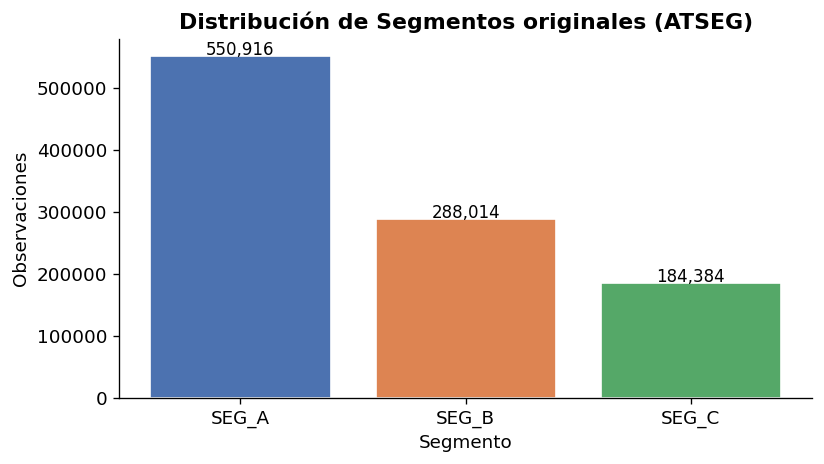

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
vc = df_raw['ATSEG'].value_counts()
bars = ax.bar(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor='white')
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3000,
            f'{v:,}', ha='center', fontsize=10)
ax.set_title('Distribución de Segmentos originales (ATSEG)', fontweight='bold')
ax.set_ylabel('Observaciones')
ax.set_xlabel('Segmento')
plt.tight_layout()
plt.savefig('distribucion_atseg.png', bbox_inches='tight', dpi=130)
plt.show()

## 3. Preprocesamiento

In [ ]:
FEATURES = [
    'UC_TRX', 'ORAL_TRX', 'IL23_TRX',
    'BRAND1_TRX', 'BRAND2_TRX',
    'UC_NRX', 'ORAL_NRX', 'IL23_NRX',
    'BRAND1_NRX', 'BRAND2_NRX',
    'BRAND1_NBRX', 'BRAND2_NBRX',
    'ORAL_NBRX', 'IL23_NBRX',
    'RTE', 'SAMPLES', 'COPAY', 'DIRECTMAIL', 'SPK', 'DETAILS',
    'UC_TRX_R4_16SUM', 'ORAL_NBRX_R4_29SUM', 'IL23_NBRX_R4_29SUM'
]

df = df_raw[FEATURES].fillna(df_raw[FEATURES].median())

np.random.seed(42)
SAMPLE_SIZE = 50_000
idx_main = np.random.choice(len(df), SAMPLE_SIZE, replace=False)
df_sample = df.iloc[idx_main].reset_index(drop=True)
atseg_sample = df_raw['ATSEG'].iloc[idx_main].reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

TOP_FEAT = ['UC_TRX','ORAL_TRX','IL23_TRX','BRAND1_TRX','BRAND2_TRX',
            'SAMPLES','DETAILS','RTE','UC_TRX_R4_16SUM']
PLOT_FEAT = ['UC_TRX','ORAL_TRX','IL23_TRX','BRAND1_TRX','BRAND2_TRX','SAMPLES','DETAILS']

print(f'Muestra: {len(df_sample):,} registros')
print(f'Features: {len(FEATURES)}')
print(f'Varianza explicada por 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Muestra: 50,000 registros
Features: 23
Varianza explicada por 2 PCs: 32.9%


## 4. Selección del número óptimo de clusters

  k=2  inertia=   1,000,170  silhouette=0.8042


  k=3  inertia=     939,124  silhouette=0.7974


  k=4  inertia=     885,606  silhouette=0.7265


  k=5  inertia=     837,605  silhouette=0.8004


  k=6  inertia=     785,732  silhouette=0.5670


  k=7  inertia=     732,713  silhouette=0.6760


  k=8  inertia=     682,794  silhouette=0.6697


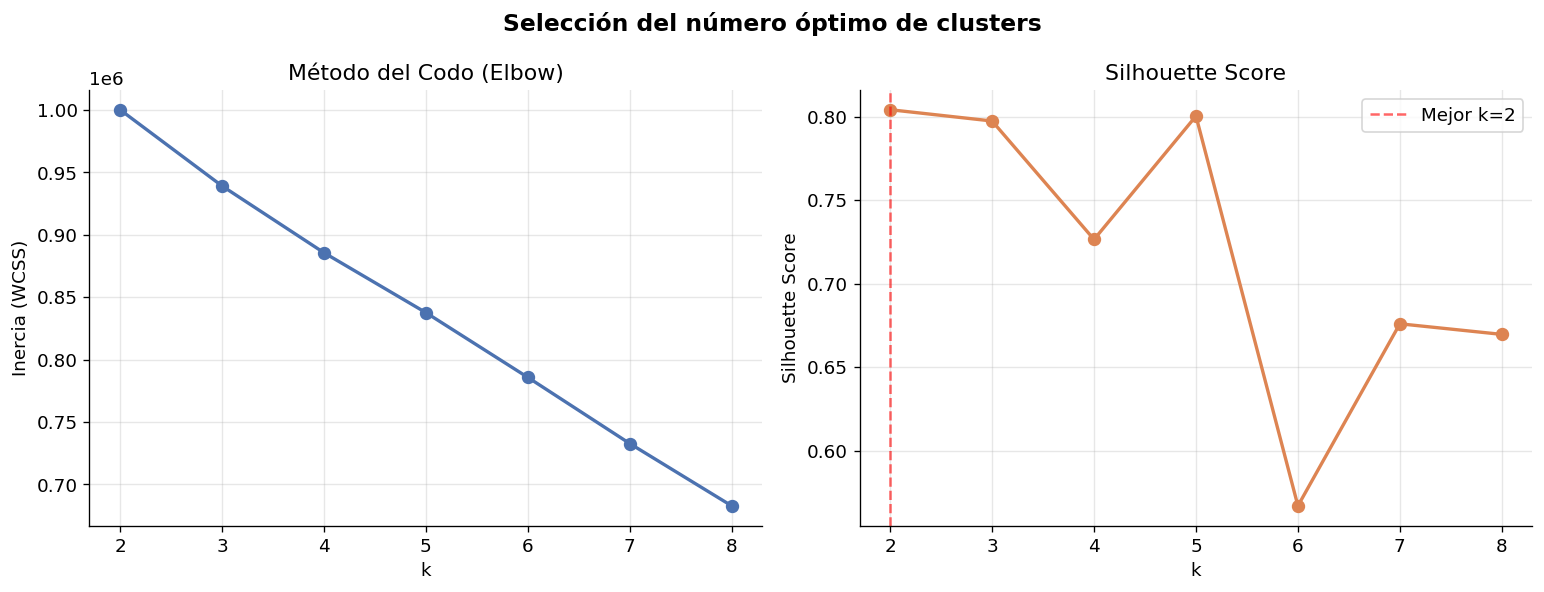

k optimo: 2


In [ ]:
K_range = range(2, 9)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labs, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f'  k={k}  inertia={km.inertia_:>12,.0f}  silhouette={sil:.4f}')

K_OPT = list(K_range)[np.argmax(silhouettes)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Selección del número óptimo de clusters', fontsize=14, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'o-', color='#4C72B0', lw=2, ms=7)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo (Elbow)'); axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'o-', color='#DD8452', lw=2, ms=7)
axes[1].axvline(x=K_OPT, color='red', ls='--', alpha=0.6, label=f'Mejor k={K_OPT}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].set_xticks(list(K_range))
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'k optimo: {K_OPT}')

## 5. K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_kmeans = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, labels_kmeans, sample_size=5000, random_state=42)
db_km  = davies_bouldin_score(X_scaled, labels_kmeans)
ch_km  = calinski_harabasz_score(X_scaled, labels_kmeans)

print(f'K-Means  (k={K_OPT})')
print(f'  Silhouette:        {sil_km:.4f}  (mayor = mejor)')
print(f'  Davies-Bouldin:    {db_km:.4f}  (menor = mejor)')
print(f'  Calinski-Harabasz: {ch_km:.2f} (mayor = mejor)')

K-Means  (k=2)
  Silhouette:        0.8042  (mayor = mejor)
  Davies-Bouldin:    1.4328  (menor = mejor)
  Calinski-Harabasz: 7489.96 (mayor = mejor)


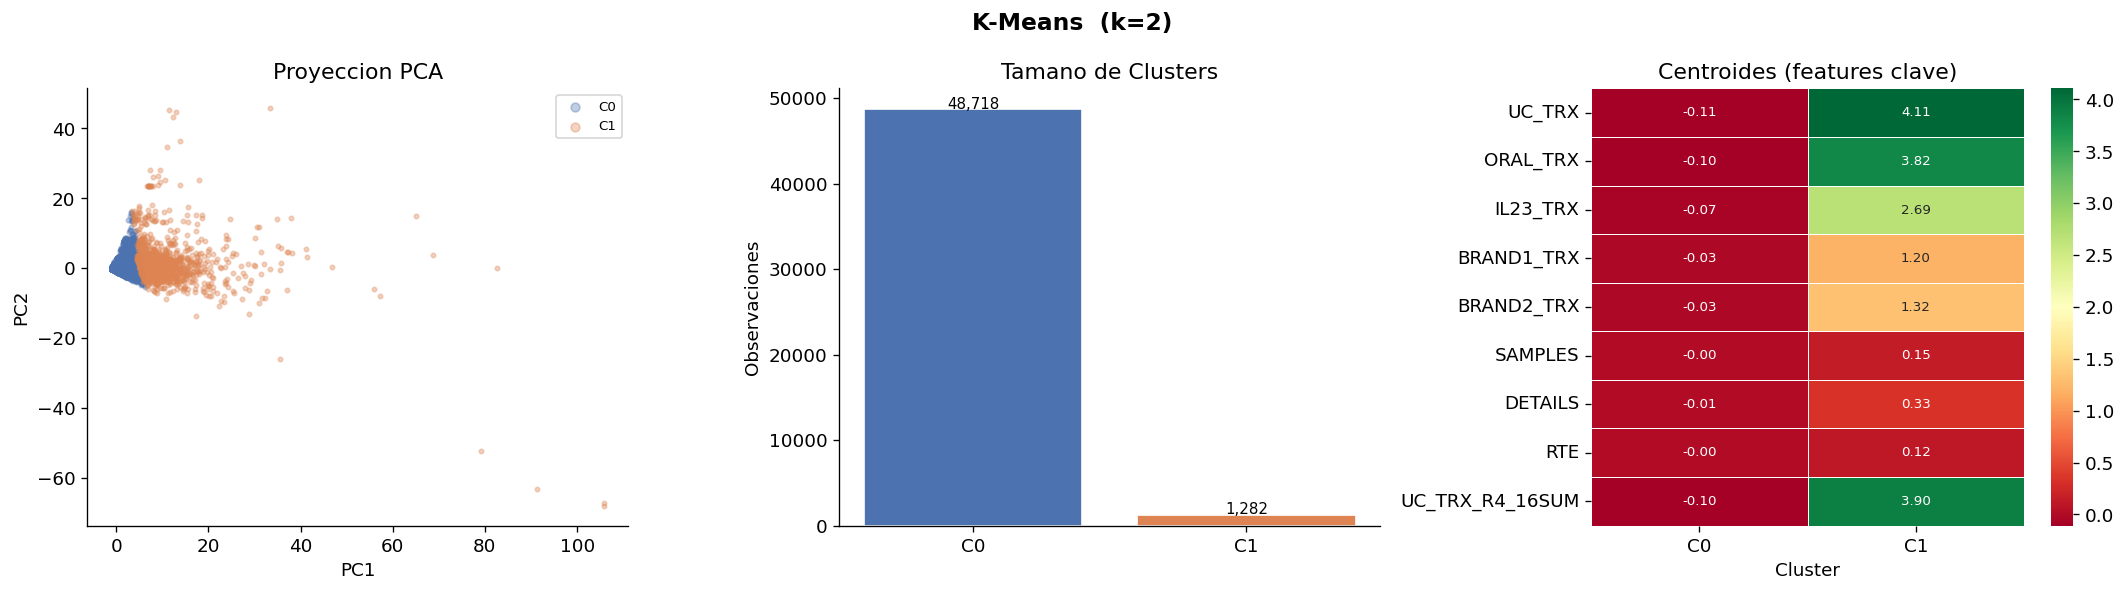

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'K-Means  (k={K_OPT})', fontsize=14, fontweight='bold')

for c in range(K_OPT):
    m = labels_kmeans == c
    axes[0].scatter(X_pca[m,0], X_pca[m,1], s=7, alpha=0.35, color=PALETTE[c], label=f'C{c}')
axes[0].set_title('Proyeccion PCA'); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=8)

u, cnt = np.unique(labels_kmeans, return_counts=True)
bars = axes[1].bar([f'C{c}' for c in u], cnt, color=[PALETTE[i] for i in u], edgecolor='white')
for bar, v in zip(bars, cnt):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{v:,}', ha='center', fontsize=9)
axes[1].set_title('Tamano de Clusters'); axes[1].set_ylabel('Observaciones')

centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=FEATURES)
sns.heatmap(centers_df[TOP_FEAT].T, ax=axes[2], cmap='RdYlGn',
            xticklabels=[f'C{c}' for c in range(K_OPT)],
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size':8})
axes[2].set_title('Centroides (features clave)'); axes[2].set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('kmeans_main.png', bbox_inches='tight', dpi=130)
plt.show()

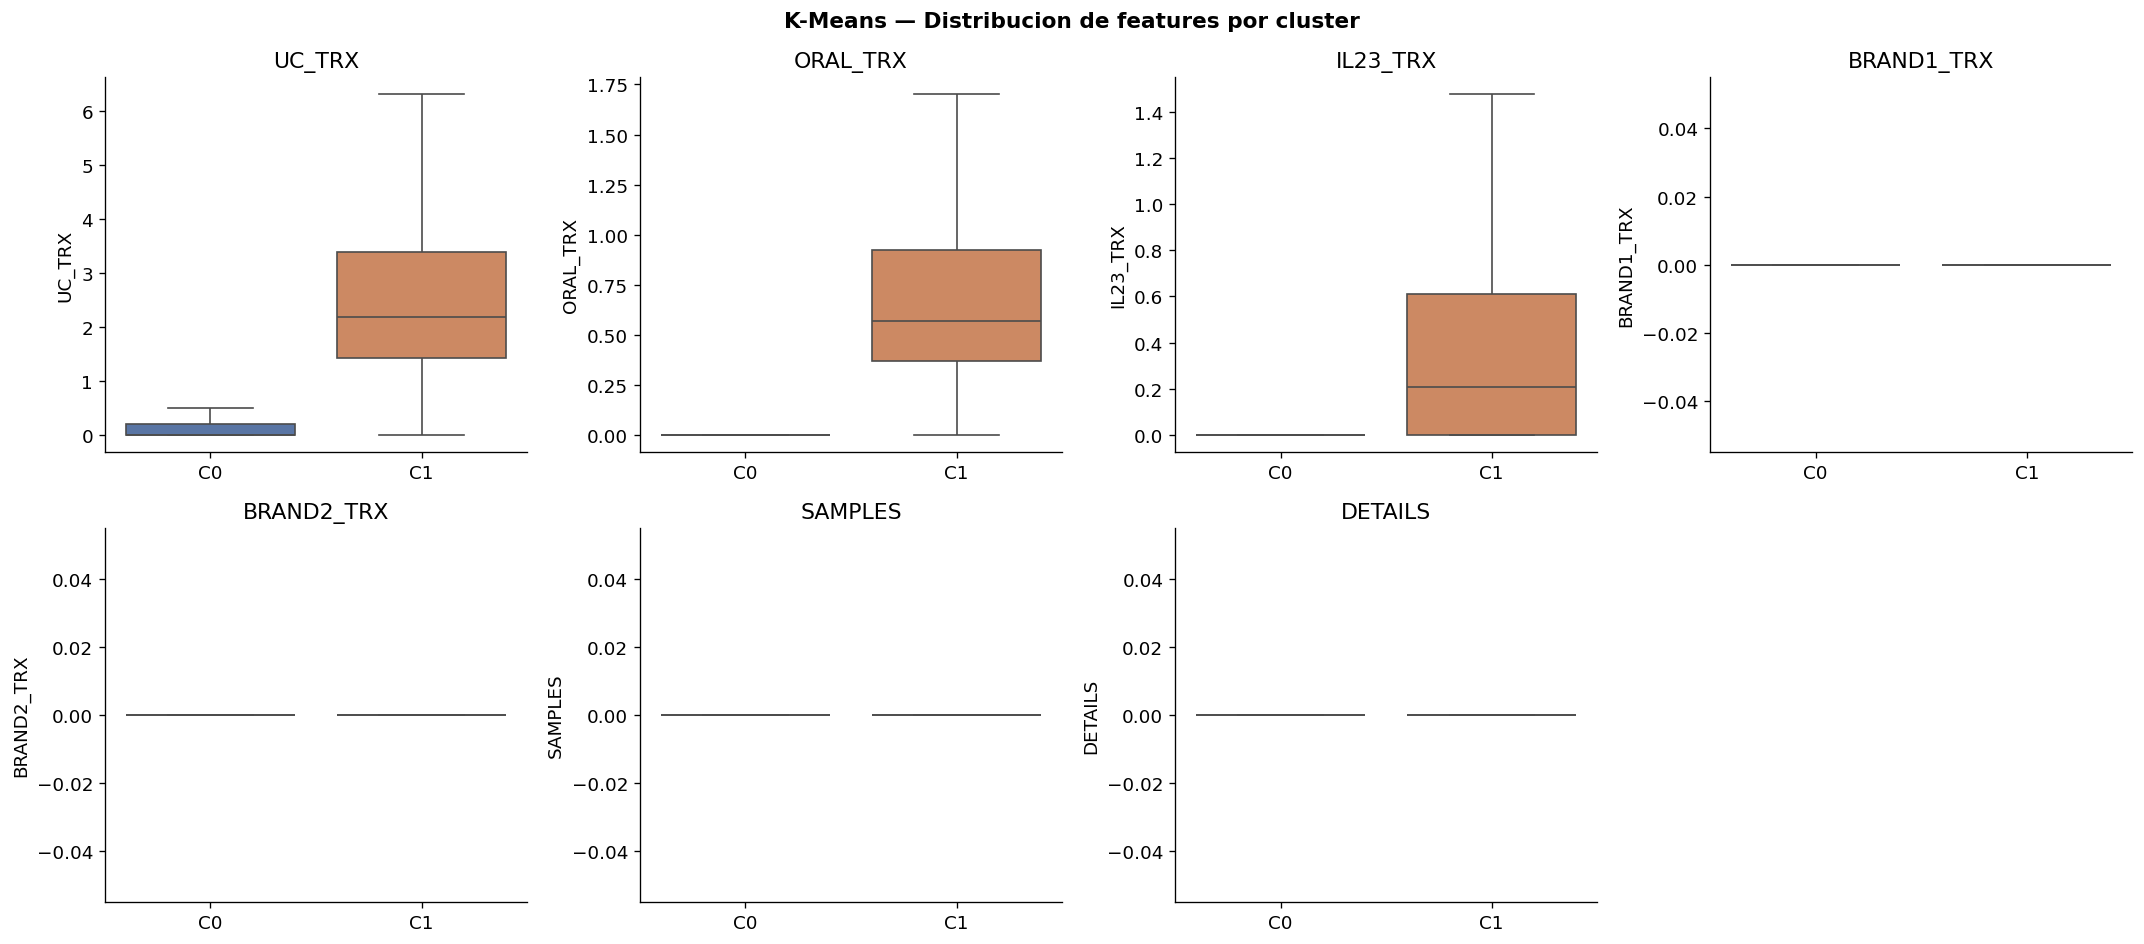

In [ ]:
df_km = df_sample.copy()
df_km['Cluster'] = [f'C{l}' for l in labels_kmeans]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('K-Means — Distribucion de features por cluster', fontsize=13, fontweight='bold')
axes = axes.flatten()
order_km = sorted(df_km['Cluster'].unique())
for i, feat in enumerate(PLOT_FEAT):
    sns.boxplot(data=df_km, x='Cluster', y=feat, palette=PALETTE[:K_OPT],
                ax=axes[i], showfliers=False, order=order_km)
    axes[i].set_title(feat); axes[i].set_xlabel('')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('kmeans_boxplots.png', bbox_inches='tight', dpi=130)
plt.show()

## 6. K-Medoids (PAM)

In [ ]:
np.random.seed(42)
KMED_SIZE = 10_000
idx_kmed   = np.random.choice(len(df_sample), KMED_SIZE, replace=False)
X_kmed     = X_scaled[idx_kmed]
X_pca_kmed = X_pca[idx_kmed]

kmedoids = KMedoids(n_clusters=K_OPT, random_state=42, max_iter=150)
labels_kmed = kmedoids.fit_predict(X_kmed)

sil_kmed = silhouette_score(X_kmed, labels_kmed, sample_size=3000, random_state=42)
db_kmed  = davies_bouldin_score(X_kmed, labels_kmed)
ch_kmed  = calinski_harabasz_score(X_kmed, labels_kmed)

print(f'K-Medoids  (k={K_OPT}, muestra={KMED_SIZE:,})')
print(f'  Silhouette:        {sil_kmed:.4f}')
print(f'  Davies-Bouldin:    {db_kmed:.4f}')
print(f'  Calinski-Harabasz: {ch_kmed:.2f}')

K-Medoids  (k=2, muestra=10,000)
  Silhouette:        0.4498
  Davies-Bouldin:    2.1877
  Calinski-Harabasz: 798.26


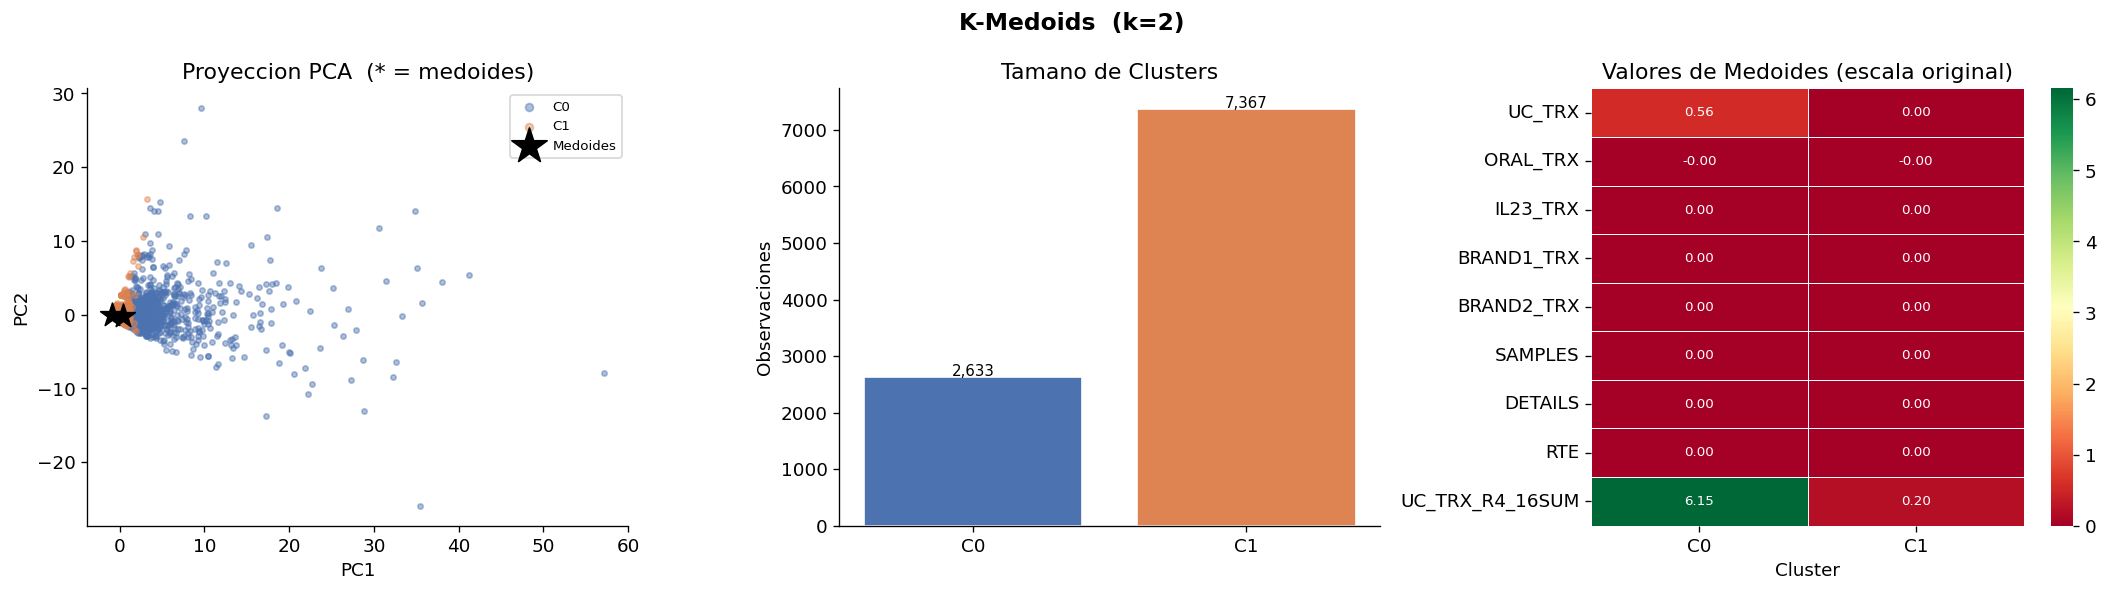

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'K-Medoids  (k={K_OPT})', fontsize=14, fontweight='bold')

for c in range(K_OPT):
    m = labels_kmed == c
    axes[0].scatter(X_pca_kmed[m,0], X_pca_kmed[m,1], s=10, alpha=0.45, color=PALETTE[c], label=f'C{c}')
med_pca = X_pca_kmed[kmedoids.medoid_indices_]
axes[0].scatter(med_pca[:,0], med_pca[:,1], s=220, marker='*', color='black', zorder=5, label='Medoides')
axes[0].set_title('Proyeccion PCA  (* = medoides)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=1.5, fontsize=8)

u_km, cnt_km = np.unique(labels_kmed, return_counts=True)
bars2 = axes[1].bar([f'C{c}' for c in u_km], cnt_km,
                     color=[PALETTE[i] for i in u_km], edgecolor='white')
for bar, v in zip(bars2, cnt_km):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{v:,}', ha='center', fontsize=9)
axes[1].set_title('Tamano de Clusters'); axes[1].set_ylabel('Observaciones')

med_vals = scaler.inverse_transform(X_kmed[kmedoids.medoid_indices_])
med_df   = pd.DataFrame(med_vals, columns=FEATURES)
sns.heatmap(med_df[TOP_FEAT].T, ax=axes[2], cmap='RdYlGn',
            xticklabels=[f'C{c}' for c in range(K_OPT)],
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size':8})
axes[2].set_title('Valores de Medoides (escala original)'); axes[2].set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('kmedoids_main.png', bbox_inches='tight', dpi=130)
plt.show()

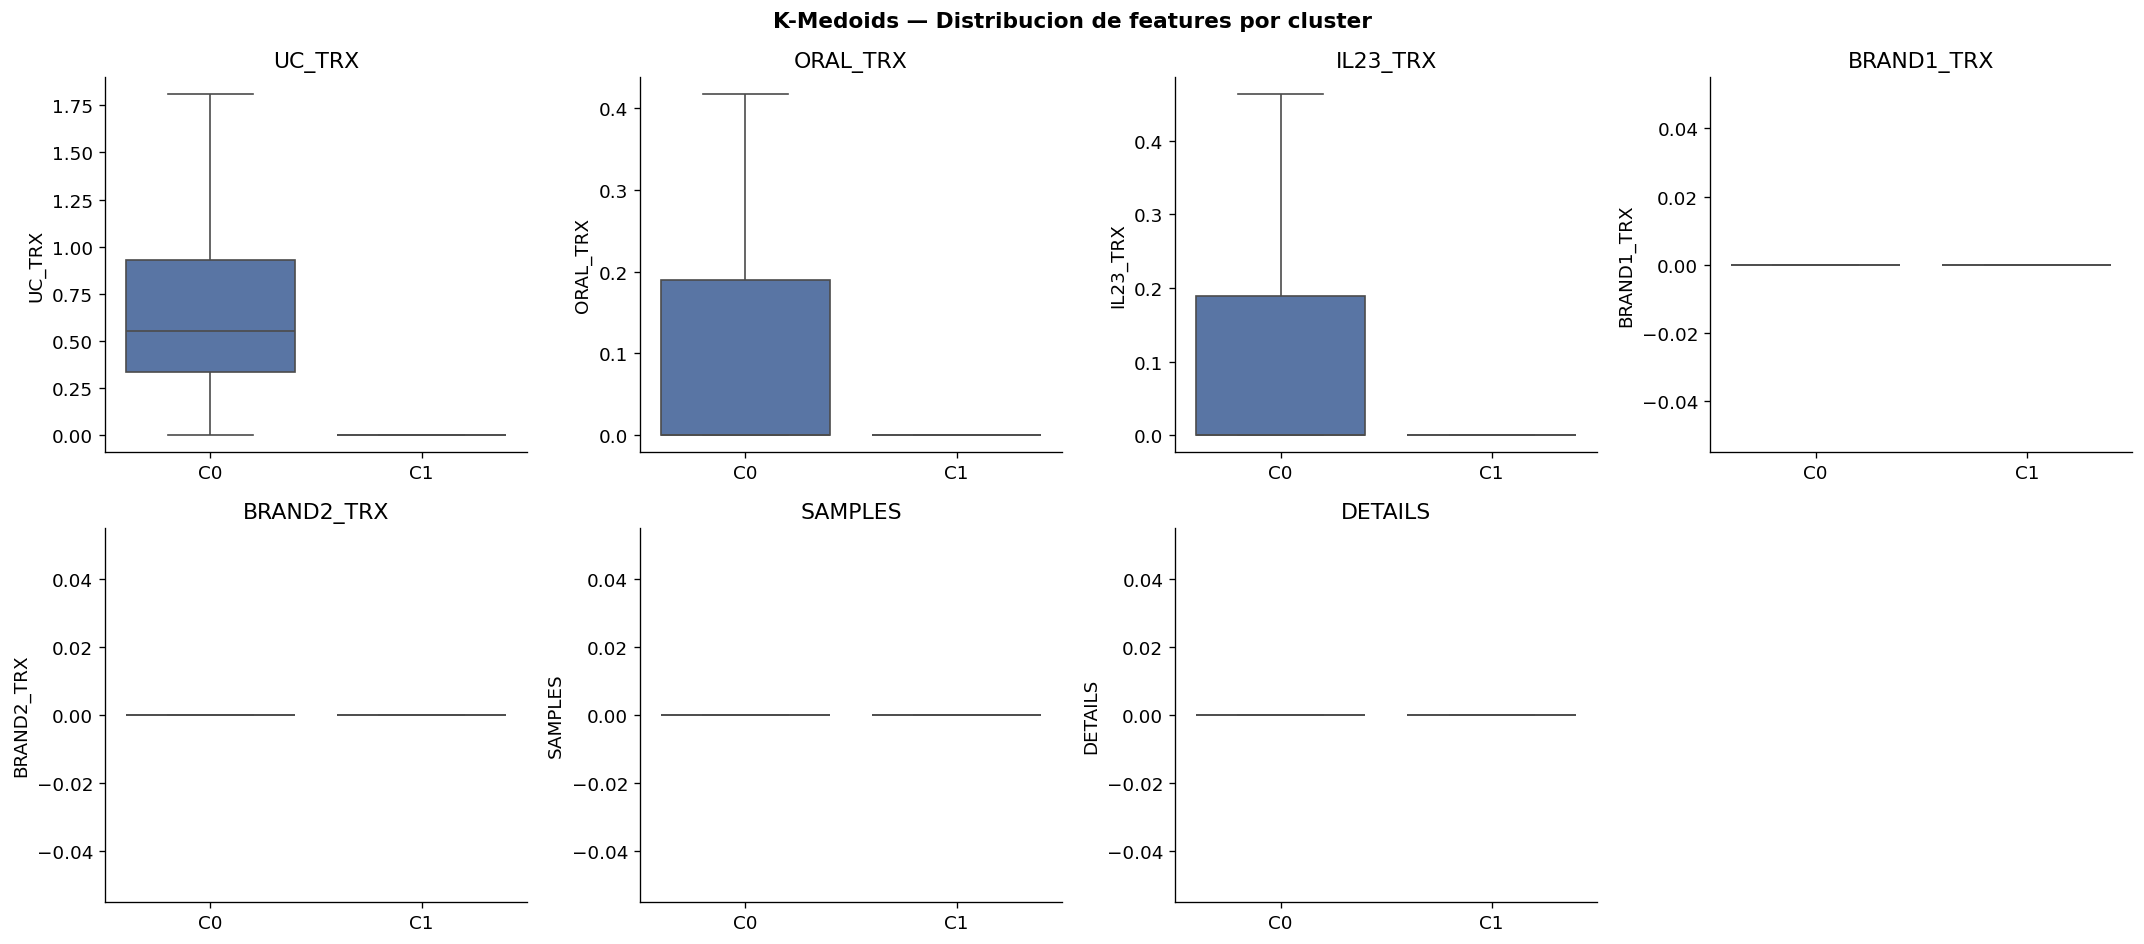

In [ ]:
df_kmed_plot = df_sample.iloc[idx_kmed].reset_index(drop=True).copy()
df_kmed_plot['Cluster'] = [f'C{l}' for l in labels_kmed]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('K-Medoids — Distribucion de features por cluster', fontsize=13, fontweight='bold')
axes = axes.flatten()
order_kmed = sorted(df_kmed_plot['Cluster'].unique())
for i, feat in enumerate(PLOT_FEAT):
    sns.boxplot(data=df_kmed_plot, x='Cluster', y=feat, palette=PALETTE[:K_OPT],
                ax=axes[i], showfliers=False, order=order_kmed)
    axes[i].set_title(feat); axes[i].set_xlabel('')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('kmedoids_boxplots.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. DBSCAN

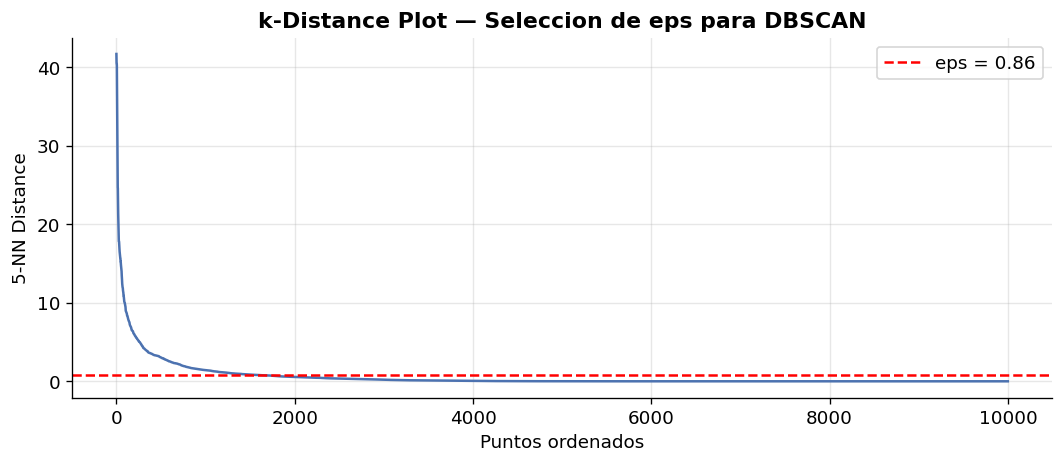

eps seleccionado: 0.86


In [ ]:
np.random.seed(42)
DBSCAN_SIZE = 10_000
idx_db   = np.random.choice(len(df_sample), DBSCAN_SIZE, replace=False)
X_db     = X_scaled[idx_db]
X_pca_db = X_pca[idx_db]

nbrs = NearestNeighbors(n_neighbors=5).fit(X_db)
distances, _ = nbrs.kneighbors(X_db)
k_distances  = np.sort(distances[:, -1])[::-1]
EPS = round(float(np.percentile(k_distances, 85)), 2)

plt.figure(figsize=(9, 4))
plt.plot(k_distances, color='#4C72B0', lw=1.5)
plt.axhline(y=EPS, color='red', ls='--', label=f'eps = {EPS}')
plt.xlabel('Puntos ordenados'); plt.ylabel('5-NN Distance')
plt.title('k-Distance Plot — Seleccion de eps para DBSCAN', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdist.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'eps seleccionado: {EPS}')

In [ ]:
dbscan = DBSCAN(eps=EPS, min_samples=10, n_jobs=-1)
labels_db = dbscan.fit_predict(X_db)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = (labels_db == -1).sum()
pct_noise     = n_noise_db / len(labels_db) * 100

print(f'DBSCAN  (eps={EPS}, min_samples=10)')
print(f'  Clusters encontrados: {n_clusters_db}')
print(f'  Ruido (outliers):     {n_noise_db:,} ({pct_noise:.1f}%)')
print(f'  Distribucion top10: {dict(pd.Series(labels_db).value_counts().head(10))}')

mask_core = labels_db != -1
if n_clusters_db > 1 and mask_core.sum() > 0:
    sil_db = silhouette_score(X_db[mask_core], labels_db[mask_core],
                               sample_size=min(3000, mask_core.sum()), random_state=42)
    db_db  = davies_bouldin_score(X_db[mask_core], labels_db[mask_core])
    ch_db  = calinski_harabasz_score(X_db[mask_core], labels_db[mask_core])
    print(f'\n  Silhouette (sin ruido): {sil_db:.4f}')
    print(f'  Davies-Bouldin:         {db_db:.4f}')
    print(f'  Calinski-Harabasz:      {ch_db:.2f}')
else:
    sil_db = db_db = ch_db = float('nan')
    print('  Solo 1 cluster o todo ruido — metricas no calculables')

DBSCAN  (eps=0.86, min_samples=10)
  Clusters encontrados: 17
  Ruido (outliers):     1,508 (15.1%)
  Distribucion top10: {2: np.int64(6985), -1: np.int64(1508), 0: np.int64(422), 4: np.int64(370), 1: np.int64(240), 3: np.int64(126), 5: np.int64(75), 7: np.int64(52), 14: np.int64(43), 13: np.int64(41)}



  Silhouette (sin ruido): 0.5466
  Davies-Bouldin:         0.6472
  Calinski-Harabasz:      2290.80


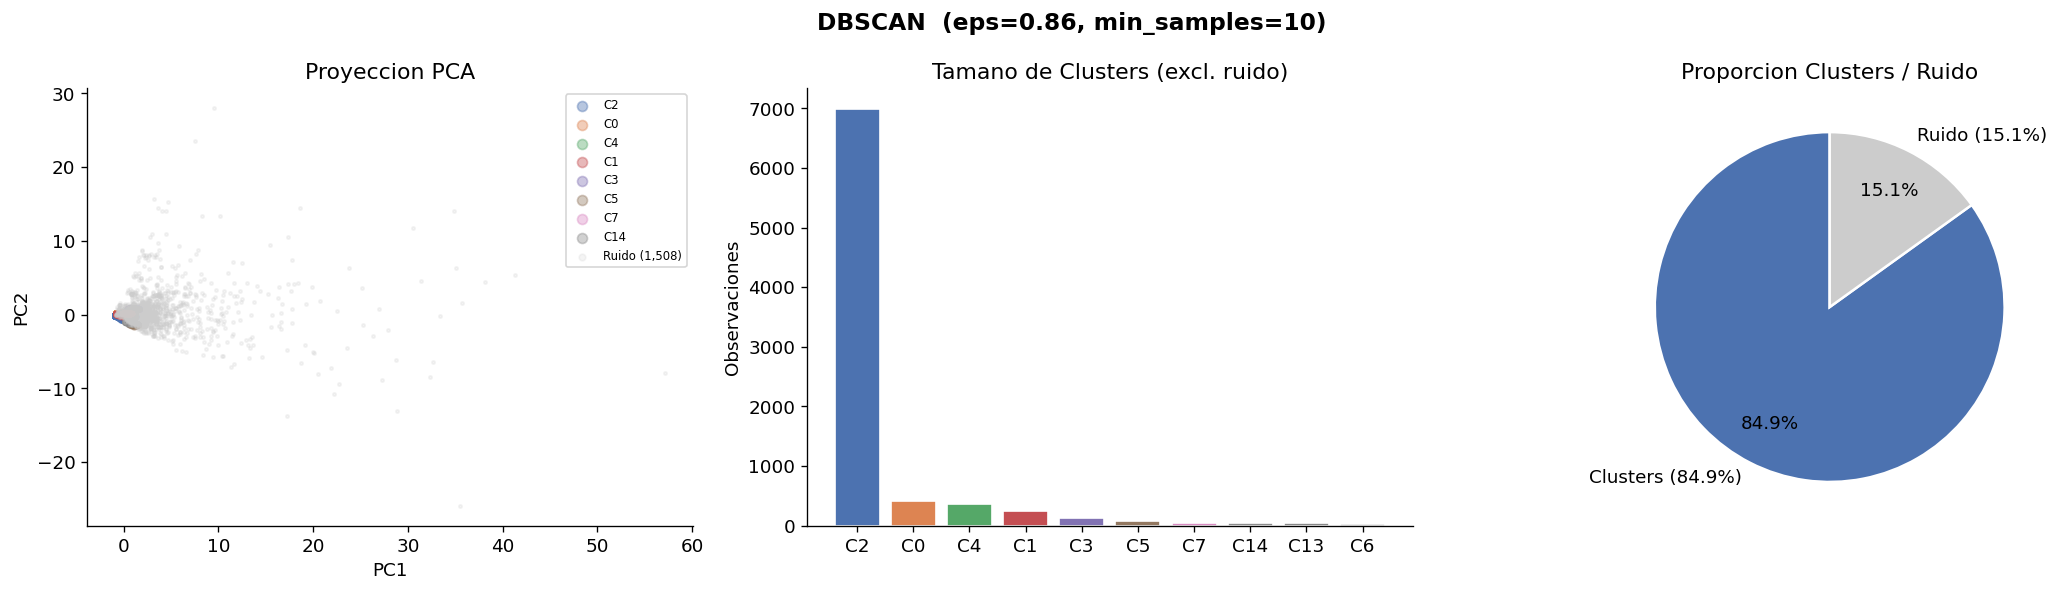

In [ ]:
top_db_cls = pd.Series(labels_db[labels_db != -1]).value_counts().head(8).index.tolist()
clr_db = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(top_db_cls)}
clr_db[-1] = '#CCCCCC'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'DBSCAN  (eps={EPS}, min_samples=10)', fontsize=14, fontweight='bold')

for c in top_db_cls:
    m = labels_db == c
    axes[0].scatter(X_pca_db[m,0], X_pca_db[m,1], s=9, alpha=0.4, color=clr_db[c], label=f'C{c}')
noise_m = labels_db == -1
axes[0].scatter(X_pca_db[noise_m,0], X_pca_db[noise_m,1], s=4, alpha=0.2, color='#CCCCCC',
                label=f'Ruido ({n_noise_db:,})')
axes[0].set_title('Proyeccion PCA'); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=7)

vc_db = pd.Series(labels_db[labels_db != -1]).value_counts().head(10)
axes[1].bar([f'C{c}' for c in vc_db.index], vc_db.values,
             color=[clr_db.get(c,'#888') for c in vc_db.index], edgecolor='white')
axes[1].set_title('Tamano de Clusters (excl. ruido)'); axes[1].set_ylabel('Observaciones')

core_pct = 100 - pct_noise
axes[2].pie([core_pct, pct_noise],
             labels=[f'Clusters ({core_pct:.1f}%)', f'Ruido ({pct_noise:.1f}%)'],
             colors=['#4C72B0', '#CCCCCC'], startangle=90, autopct='%1.1f%%',
             pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[2].set_title('Proporcion Clusters / Ruido')

plt.tight_layout()
plt.savefig('dbscan_main.png', bbox_inches='tight', dpi=130)
plt.show()

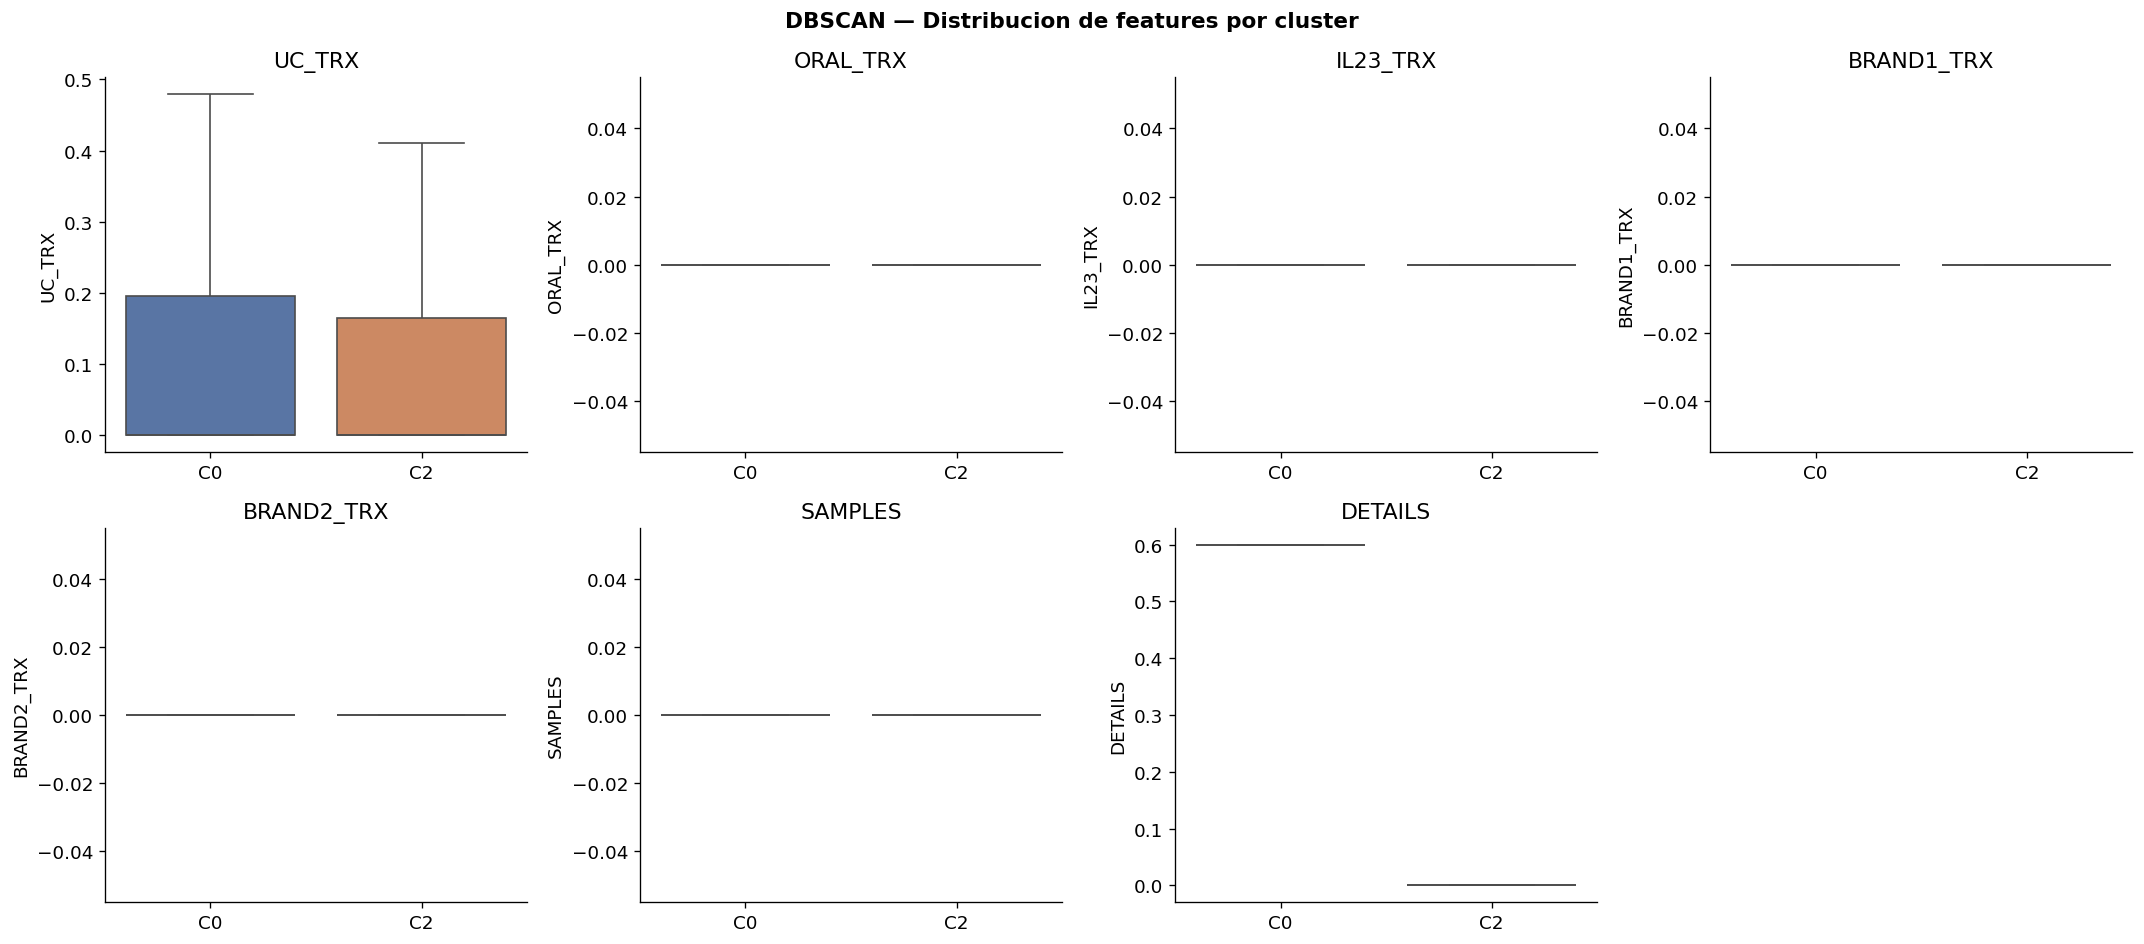

In [ ]:
df_db_plot = df_sample.iloc[idx_db].reset_index(drop=True).copy()
df_db_plot['Cluster'] = labels_db
df_db_plot = df_db_plot[df_db_plot['Cluster'].isin(top_db_cls[:K_OPT])].copy()
df_db_plot['Cluster'] = df_db_plot['Cluster'].apply(lambda x: f'C{x}')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('DBSCAN — Distribucion de features por cluster', fontsize=13, fontweight='bold')
axes = axes.flatten()
order_db = sorted(df_db_plot['Cluster'].unique())
n_db_cls = df_db_plot['Cluster'].nunique()
for i, feat in enumerate(PLOT_FEAT):
    if n_db_cls > 0:
        sns.boxplot(data=df_db_plot, x='Cluster', y=feat, palette=PALETTE[:n_db_cls],
                    ax=axes[i], showfliers=False, order=order_db)
        axes[i].set_title(feat); axes[i].set_xlabel('')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('dbscan_boxplots.png', bbox_inches='tight', dpi=130)
plt.show()

## 8. Comparación de algoritmos

In [ ]:
metrics = pd.DataFrame({
    'Algoritmo':           ['K-Means',  'K-Medoids', 'DBSCAN'],
    'Clusters':            [K_OPT,       K_OPT,       n_clusters_db],
    'Muestra':             [f'{len(df_sample):,}', f'{KMED_SIZE:,}', f'{DBSCAN_SIZE:,}'],
    'Silhouette (>mejor)': [round(sil_km,4), round(sil_kmed,4),
                            round(sil_db,4) if sil_db==sil_db else 'N/A'],
    'Davies-Bouldin (<mejor)': [round(db_km,4), round(db_kmed,4),
                                 round(db_db,4) if db_db==db_db else 'N/A'],
    'Calinski-Harabasz (>mejor)': [round(ch_km,1), round(ch_kmed,1),
                                    round(ch_db,1) if ch_db==ch_db else 'N/A'],
    'Ruido (%)':           ['0%', '0%', f'{pct_noise:.1f}%'],
    'Formas':              ['Esfericas', 'Esfericas', 'Arbitrarias'],
    'Outliers':            ['No maneja', 'Robusto', 'Etiqueta como ruido'],
})

print(metrics.to_string(index=False))
metrics

Algoritmo  Clusters Muestra  Silhouette (>mejor)  Davies-Bouldin (<mejor)  Calinski-Harabasz (>mejor) Ruido (%)      Formas            Outliers
  K-Means         2  50,000               0.8042                   1.4328                      7490.0        0%   Esfericas           No maneja
K-Medoids         2  10,000               0.4498                   2.1877                       798.3        0%   Esfericas             Robusto
   DBSCAN        17  10,000               0.5466                   0.6472                      2290.8     15.1% Arbitrarias Etiqueta como ruido


,Algoritmo,Clusters,Muestra,Silhouette (>mejor),Davies-Bouldin (<mejor),Calinski-Harabasz (>mejor),Ruido (%),Formas,Outliers
0,K-Means,2,"50,000",0.8042,1.4328,7490.0,0%,Esfericas,No maneja
1,K-Medoids,2,"10,000",0.4498,2.1877,798.3,0%,Esfericas,Robusto
2,DBSCAN,17,"10,000",0.5466,0.6472,2290.8,15.1%,Arbitrarias,Etiqueta como ruido


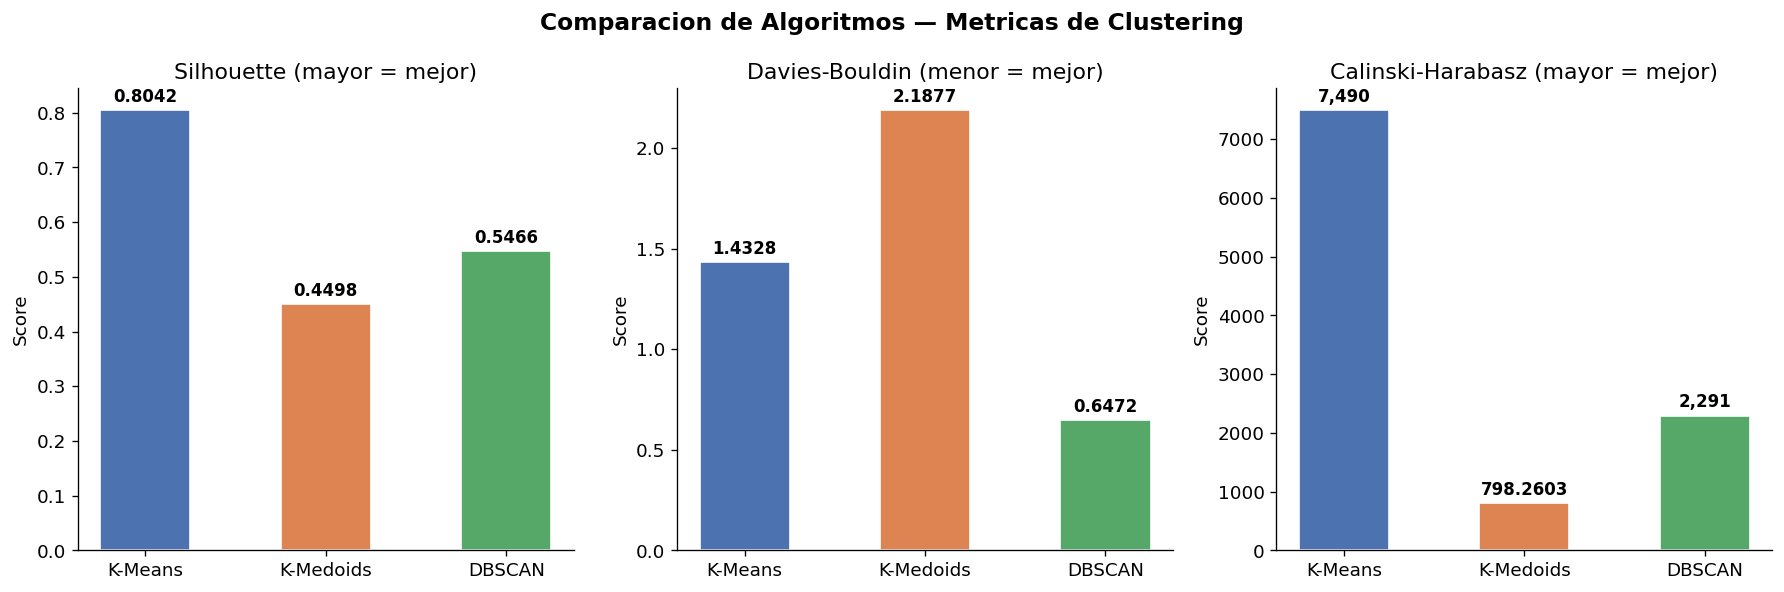

In [ ]:
algos = ['K-Means', 'K-Medoids']
sils  = [sil_km, sil_kmed]
dbs   = [db_km,  db_kmed]
chs   = [ch_km,  ch_kmed]
if sil_db == sil_db:  # not nan
    algos.append('DBSCAN'); sils.append(sil_db); dbs.append(db_db); chs.append(ch_db)

cols_c = PALETTE[:len(algos)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparacion de Algoritmos — Metricas de Clustering', fontsize=14, fontweight='bold')

for ax, vals, title in zip(axes,
    [sils, dbs, chs],
    ['Silhouette (mayor = mejor)', 'Davies-Bouldin (menor = mejor)', 'Calinski-Harabasz (mayor = mejor)']
):
    bars = ax.bar(algos, vals, color=cols_c, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{v:,.4f}' if v < 1000 else f'{v:,.0f}',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title); ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('comparacion_metricas.png', bbox_inches='tight', dpi=130)
plt.show()

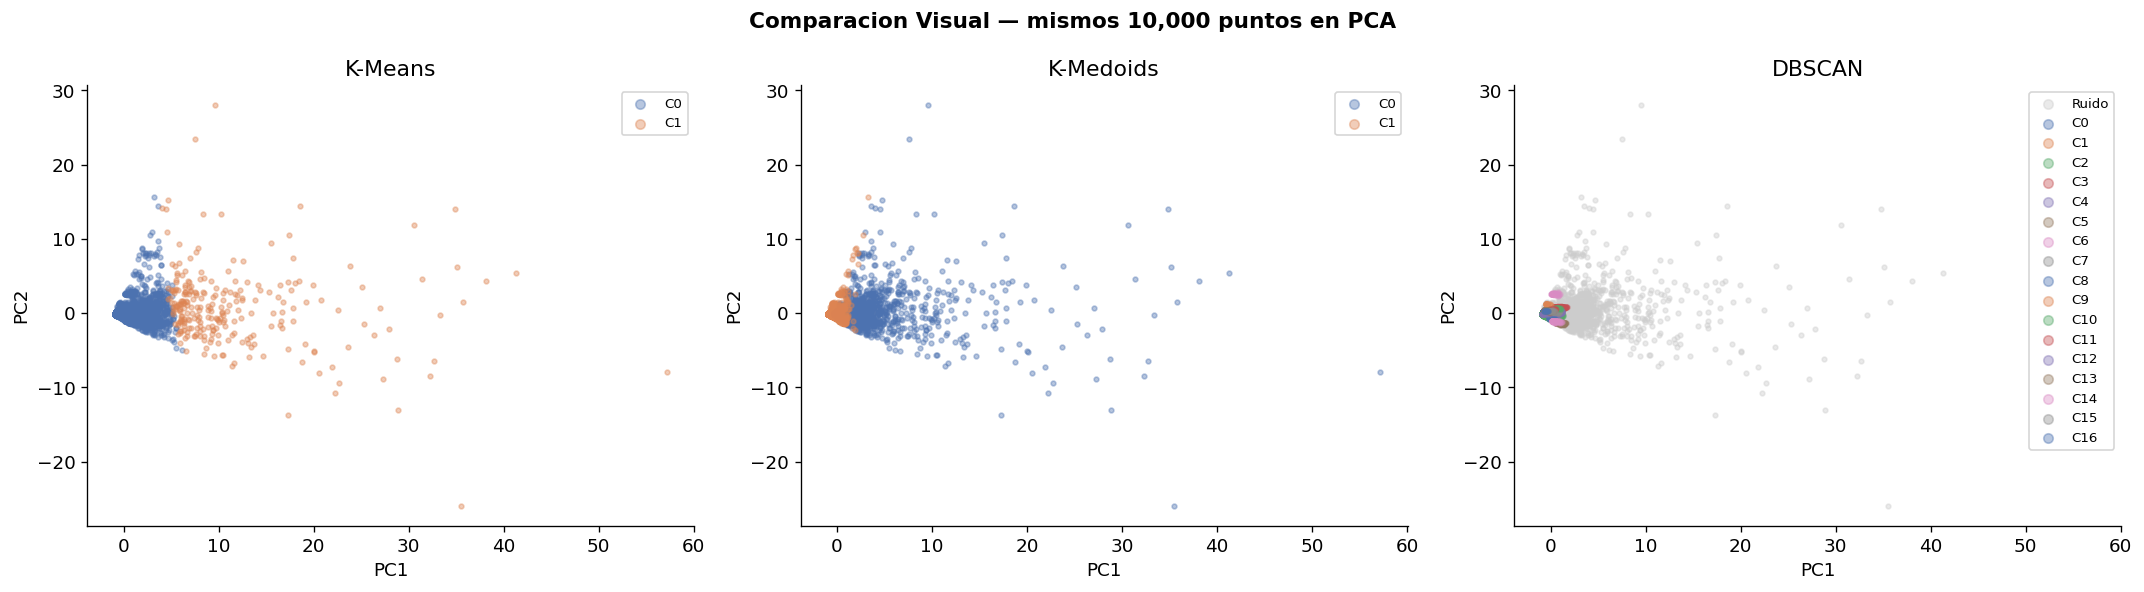

In [ ]:
# Scatter comparativo — mismos 10k puntos
labels_km_sub   = labels_kmeans[idx_db]
D_assign        = pairwise_distances(X_db, X_kmed[kmedoids.medoid_indices_])
labels_kmed_sub = np.argmin(D_assign, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparacion Visual — mismos 10,000 puntos en PCA', fontsize=13, fontweight='bold')

for ax, lbs, title in zip(axes,
    [labels_km_sub, labels_kmed_sub, labels_db],
    ['K-Means', 'K-Medoids', 'DBSCAN']
):
    for c in sorted(set(lbs)):
        m = lbs == c
        color = '#CCCCCC' if c == -1 else PALETTE[c % len(PALETTE)]
        lbl   = 'Ruido' if c == -1 else f'C{c}'
        ax.scatter(X_pca_db[m,0], X_pca_db[m,1], s=8, alpha=0.4, color=color, label=lbl)
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig('comparacion_scatter.png', bbox_inches='tight', dpi=130)
plt.show()

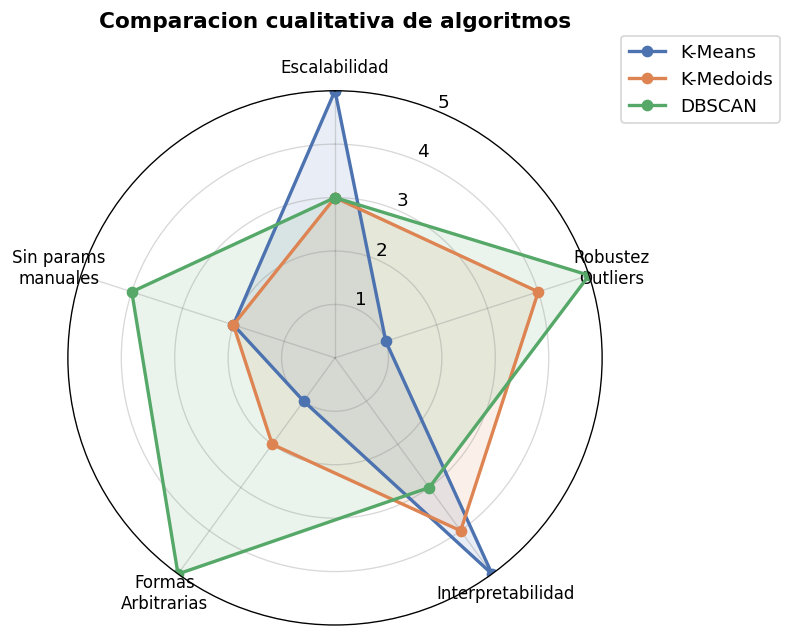

In [ ]:
# Radar chart — propiedades cualitativas
categories = ['Escalabilidad', 'Robustez\nOutliers', 'Interpretabilidad',
              'Formas\nArbitrarias', 'Sin params\nmanuales']
N = len(categories)
scores_radar = {
    'K-Means':   [5, 1, 5, 1, 2],
    'K-Medoids': [3, 4, 4, 2, 2],
    'DBSCAN':    [3, 5, 3, 5, 4],
}
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 5); ax.set_yticks([1,2,3,4,5])
ax.grid(color='gray', alpha=0.3)

for i, (algo, vals) in enumerate(scores_radar.items()):
    vp = vals + vals[:1]
    ax.plot(angles, vp, 'o-', lw=2, color=PALETTE[i], label=algo)
    ax.fill(angles, vp, alpha=0.12, color=PALETTE[i])

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), fontsize=11)
ax.set_title('Comparacion cualitativa de algoritmos', y=1.1, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_radar.png', bbox_inches='tight', dpi=130)
plt.show()

## 9. Conclusiones

| Aspecto | K-Means | K-Medoids | DBSCAN |
|---|---|---|---|
| N° de clusters | Requiere k | Requiere k | Automático |
| Representante | Centroide (sintético) | Medoide (punto real) | No aplica |
| Outliers | No los maneja | Robusto | Los etiqueta como ruido |
| Formas admitidas | Esféricas | Esféricas | Arbitrarias |
| Escalabilidad | Alta ✅ | Media | Media |
| Interpretabilidad | Alta | Alta | Media |
| Parámetros | k | k | eps, min_samples |

### Recomendación para VELSIPITY (1.8M registros)

- **K-Means** es el más adecuado para producción dado el volumen de datos. Los centroides permiten caracterizar perfiles de prescriptores de forma clara.

- **K-Medoids** es preferible cuando se necesita un médico/prescriptor real como representante del cluster (ej. selección de Key Opinion Leaders o definición de targets para ventas).

- **DBSCAN** es útil para identificar prescriptores atípicos con comportamientos muy diferentes a la masa, o para descubrir nichos no capturados por métodos de centroides.

> **Nota:** El dataset contiene la columna `ATSEG` (SEG_A, SEG_B, SEG_C) como segmentación previa. Se recomienda cruzar los clusters obtenidos con esta variable para validar externamente los resultados.